In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Chart styling ──
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

BRAND_COLORS = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED', '#0891B2']

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

In [9]:
df = pd.read_csv('/sales_data_cleaned (3).csv', parse_dates=['order_date'])
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"Null count: {df.isnull().sum().sum()}")
df.head()

Shape: 12,000 rows × 27 columns
Date range: 2025-01-01 → 2025-12-28
Null count: 0


,order_id,order_date,region,sales_rep,customer_segment,product_category,product_name,unit_price,units_sold,discount_pct,revenue,cogs,daily_target,order_month,order_month_name,order_quarter,order_week,order_dayofweek,is_weekend,gross_profit,gross_margin_pct,revenue_per_month,discount_amount,order_tier,margin_health,target_achievement,above_target
0,ORD-110288,2025-09-19,Southeast,Sofia Rodriguez,Consumer,Electronics,Portable Charger,530.00,5,0.05,2517.50,2069.45,1400.00,9,Sep,Q3,38,Friday,False,448.05,0.18,503.50,132.50,Enterprise ($1500+),Low,1.80,True
1,ORD-109681,2025-01-13,West,Ryan Mitchell,Corporate,Apparel,Winter Jacket,73.26,24,0.00,1758.24,858.16,1133.33,1,Jan,Q1,3,Monday,False,900.08,0.51,73.26,0.00,Enterprise ($1500+),Strong,1.55,True
2,ORD-102901,2025-10-08,Southeast,Sofia Rodriguez,Small Business,Electronics,Tablet,202.10,5,0.05,959.97,874.52,1466.67,10,Oct,Q4,41,Wednesday,False,85.45,0.09,191.99,50.53,Large ($500-1500),Critical,0.65,False
3,ORD-111256,2025-01-26,Southwest,Olivia Foster,Corporate,Electronics,Webcam,373.55,16,0.05,5677.96,5203.15,1133.33,1,Jan,Q1,4,Sunday,True,474.81,0.08,354.87,298.84,Enterprise ($1500+),Critical,5.01,True
4,ORD-108351,2025-01-22,Southwest,Carlos Mendez,Corporate,Sports,Dumbbells,108.45,10,0.05,1030.27,763.70,1133.33,1,Jan,Q1,4,Wednesday,False,266.57,0.26,103.03,54.22,Large ($500-1500),Healthy,0.91,False


In [10]:
total_revenue    = df['revenue'].sum()
total_orders     = len(df)
aov              = df['revenue'].mean()
total_units      = df['units_sold'].sum()
gross_profit     = df['gross_profit'].sum()
avg_margin       = df['gross_margin_pct'].mean()
avg_discount     = df['discount_pct'].mean()
total_target     = df['daily_target'].sum()
target_ach       = total_revenue / total_target
unique_reps      = df[df['sales_rep'] != 'Unknown']['sales_rep'].nunique()

print("━" * 45)
print("  ANNUAL PERFORMANCE SUMMARY")
print("━" * 45)
print(f"  Total Revenue:       ${total_revenue:>12,.2f}")
print(f"  Gross Profit:        ${gross_profit:>12,.2f}")
print(f"  Avg Gross Margin:    {avg_margin:>12.1%}")
print(f"  Total Orders:        {total_orders:>12,}")
print(f"  Avg Order Value:     ${aov:>12,.2f}")
print(f"  Total Units Sold:    {total_units:>12,}")
print(f"  Avg Discount:        {avg_discount:>12.1%}")
print(f"  Target Achievement:  {target_ach:>12.1%}")
print(f"  Active Sales Reps:   {unique_reps:>12}")
print("━" * 45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ANNUAL PERFORMANCE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Revenue:       $13,572,415.49
  Gross Profit:        $3,024,901.94
  Avg Gross Margin:           30.2%
  Total Orders:              12,000
  Avg Order Value:     $    1,131.03
  Total Units Sold:          63,164
  Avg Discount:                5.6%
  Target Achievement:         80.0%
  Active Sales Reps:             12
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


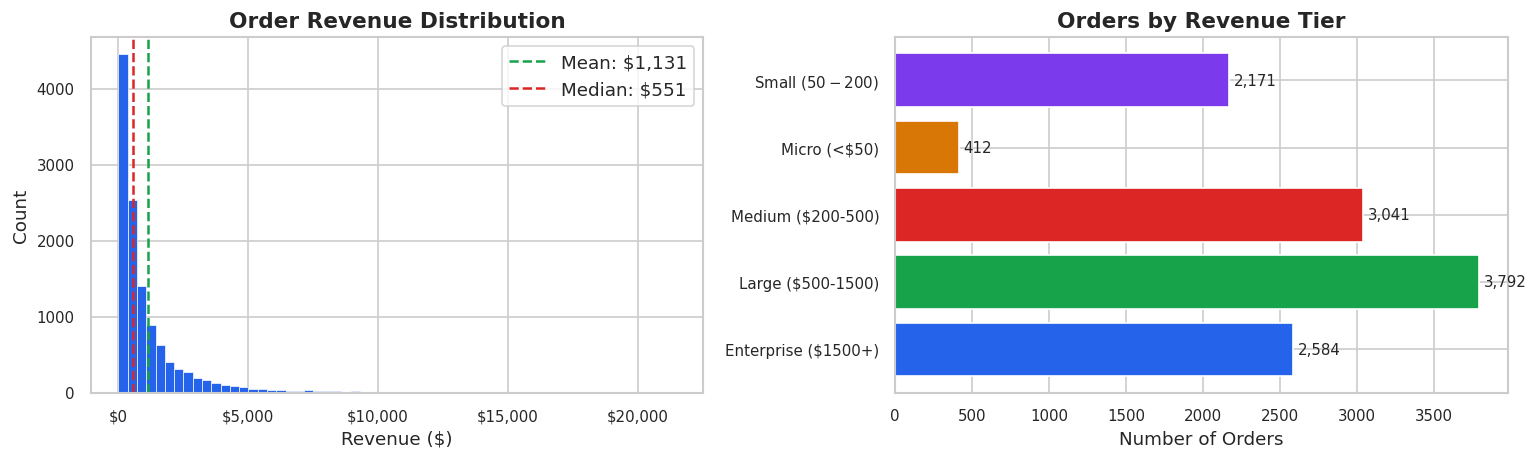

Insight: Right-skewed distribution — most orders are sub-$500 but a long tail of large orders drives disproportionate revenue.


In [11]:
import os

# Revenue distribution — understanding spread across orders
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['revenue'], bins=60, color=BRAND_COLORS[0], edgecolor='white', linewidth=0.4)
axes[0].axvline(aov, color=BRAND_COLORS[1], linestyle='--', linewidth=1.5, label=f'Mean: ${aov:,.0f}')
axes[0].axvline(df['revenue'].median(), color=BRAND_COLORS[2], linestyle='--', linewidth=1.5,
                label=f'Median: ${df["revenue"].median():,.0f}')
axes[0].set_title('Order Revenue Distribution')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# Order tier breakdown
tier_counts = df['order_tier'].value_counts().sort_index()
bars = axes[1].barh(tier_counts.index, tier_counts.values, color=BRAND_COLORS[:len(tier_counts)])
for bar, val in zip(bars, tier_counts.values):
    axes[1].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[1].set_title('Orders by Revenue Tier')
axes[1].set_xlabel('Number of Orders')

plt.tight_layout()

# Create directory if it doesn't exist
output_dir = '../data/cleaned/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, '01_revenue_distribution.png'), bbox_inches='tight')
plt.show()
print("Insight: Right-skewed distribution — most orders are sub-$500 but a long tail of large orders drives disproportionate revenue.")

In [12]:
# Monthly aggregation
monthly = (
    df.groupby('order_month')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'count'),
        aov=('revenue', 'mean'),
        gross_profit=('gross_profit', 'sum'),
        margin=('gross_margin_pct', 'mean')
    )
    .reset_index()
)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = monthly['order_month'].apply(lambda x: month_labels[x-1])
monthly['mom_growth'] = monthly['revenue'].pct_change() * 100
monthly['revenue_running'] = monthly['revenue'].cumsum()

monthly

,order_month,revenue,orders,aov,gross_profit,margin,month_name,mom_growth,revenue_running
0,1,997556.31,842,1184.75,222398.26,0.30,Jan,NaN,997556.31
1,2,976983.81,805,1213.64,205853.50,0.31,Feb,-2.06,1974540.12
2,3,955745.05,852,1121.77,215798.66,0.30,Mar,-2.17,2930285.17
3,4,1048945.13,940,1115.90,231524.80,0.30,Apr,9.75,3979230.30
4,5,1032946.80,955,1081.62,230669.44,0.30,May,-1.53,5012177.10
5,6,1167532.93,1049,1113.00,257501.92,0.30,Jun,13.03,6179710.03
6,7,1185820.05,983,1206.33,248207.34,0.30,Jul,1.57,7365530.08
7,8,1024782.00,922,1111.48,240724.80,0.30,Aug,-13.58,8390312.08
8,9,1067474.83,1001,1066.41,248999.25,0.29,Sep,4.17,9457786.91
9,10,1117080.36,1030,1084.54,251650.75,0.31,Oct,4.65,10574867.27


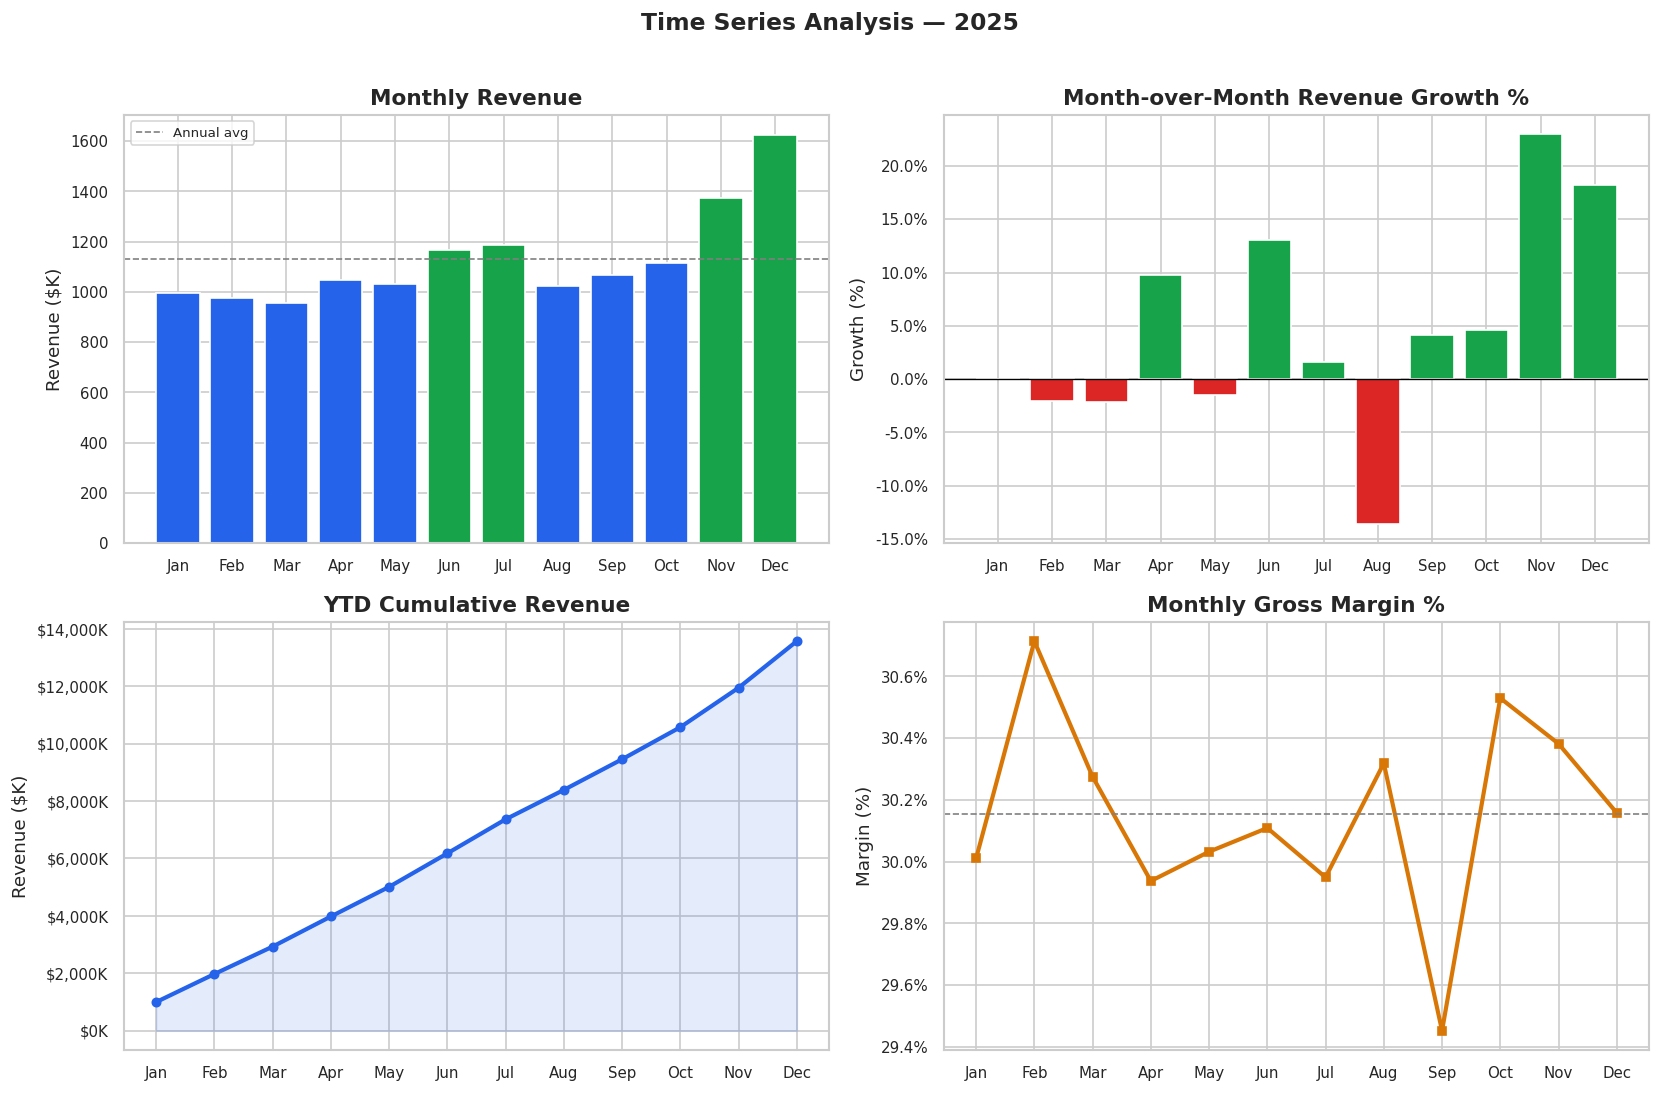

Insight: Peak month = Dec | Slowest month = Mar
Q4 (Oct–Dec) accounts for 30.3% of annual revenue.


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Monthly Revenue
ax = axes[0, 0]
bars = ax.bar(monthly['month_name'], monthly['revenue'] / 1000,
              color=[BRAND_COLORS[1] if v >= monthly['revenue'].mean() else BRAND_COLORS[0]
                     for v in monthly['revenue']])
ax.axhline(monthly['revenue'].mean() / 1000, color='gray', linestyle='--', linewidth=1, label='Annual avg')
ax.set_title('Monthly Revenue')
ax.set_ylabel('Revenue ($K)')
ax.legend(fontsize=8)

# MoM Growth %
ax = axes[0, 1]
colors = [BRAND_COLORS[1] if v >= 0 else BRAND_COLORS[2] for v in monthly['mom_growth'].fillna(0)]
ax.bar(monthly['month_name'], monthly['mom_growth'].fillna(0), color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Month-over-Month Revenue Growth %')
ax.set_ylabel('Growth (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# YTD Cumulative Revenue
ax = axes[1, 0]
ax.plot(monthly['month_name'], monthly['revenue_running'] / 1000,
        color=BRAND_COLORS[0], linewidth=2.5, marker='o', markersize=5)
ax.fill_between(monthly['month_name'], monthly['revenue_running'] / 1000,
                alpha=0.12, color=BRAND_COLORS[0])
ax.set_title('YTD Cumulative Revenue')
ax.set_ylabel('Revenue ($K)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))

# Monthly Gross Margin %
ax = axes[1, 1]
ax.plot(monthly['month_name'], monthly['margin'] * 100,
        color=BRAND_COLORS[3], linewidth=2.5, marker='s', markersize=5)
ax.axhline(monthly['margin'].mean() * 100, color='gray', linestyle='--', linewidth=1)
ax.set_title('Monthly Gross Margin %')
ax.set_ylabel('Margin (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.suptitle('Time Series Analysis — 2025', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/cleaned/02_time_series.png', bbox_inches='tight')
plt.show()

best_month = monthly.loc[monthly['revenue'].idxmax(), 'month_name']
worst_month = monthly.loc[monthly['revenue'].idxmin(), 'month_name']
print(f"Insight: Peak month = {best_month} | Slowest month = {worst_month}")
print(f"Q4 (Oct–Dec) accounts for {monthly.loc[monthly['order_month'] >= 10, 'revenue'].sum() / total_revenue:.1%} of annual revenue.")

In [14]:
# Quarterly summary
quarterly = (
    df.groupby('order_quarter')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'count'),
        margin=('gross_margin_pct', 'mean'),
        gross_profit=('gross_profit', 'sum')
    )
    .reset_index()
)
quarterly['revenue_share'] = (quarterly['revenue'] / quarterly['revenue'].sum() * 100).round(1)
quarterly['margin_pct'] = (quarterly['margin'] * 100).round(2)
quarterly[['order_quarter', 'revenue', 'gross_profit', 'orders', 'revenue_share', 'margin_pct']]

,order_quarter,revenue,gross_profit,orders,revenue_share,margin_pct
0,Q1,2930285.17,644050.42,2499,21.60,30.33
1,Q2,3249424.86,719696.16,2944,23.90,30.03
2,Q3,3278076.88,737931.39,2906,24.20,29.90
3,Q4,4114628.58,923223.97,3651,30.30,30.34


In [15]:
regional = (
    df[df['region'] != 'Unknown']
    .groupby('region')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'count'),
        aov=('revenue', 'mean'),
        gross_profit=('gross_profit', 'sum'),
        margin=('gross_margin_pct', 'mean'),
        units=('units_sold', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)
regional['revenue_share'] = (regional['revenue'] / regional['revenue'].sum() * 100).round(1)
regional['rank'] = range(1, len(regional) + 1)
regional

,region,revenue,orders,aov,gross_profit,margin,units,revenue_share,rank
1,Northeast,3438043.99,3009,1142.59,749690.90,0.30,15909,25.30,1
4,West,2936953.73,2609,1125.70,652700.48,0.30,13874,21.60,2
2,Southeast,2755049.27,2486,1108.23,627537.96,0.30,12713,20.30,3
0,Midwest,2712191.07,2369,1144.87,608421.08,0.30,12792,20.00,4
3,Southwest,1728554.42,1524,1134.22,386381.78,0.30,7855,12.70,5


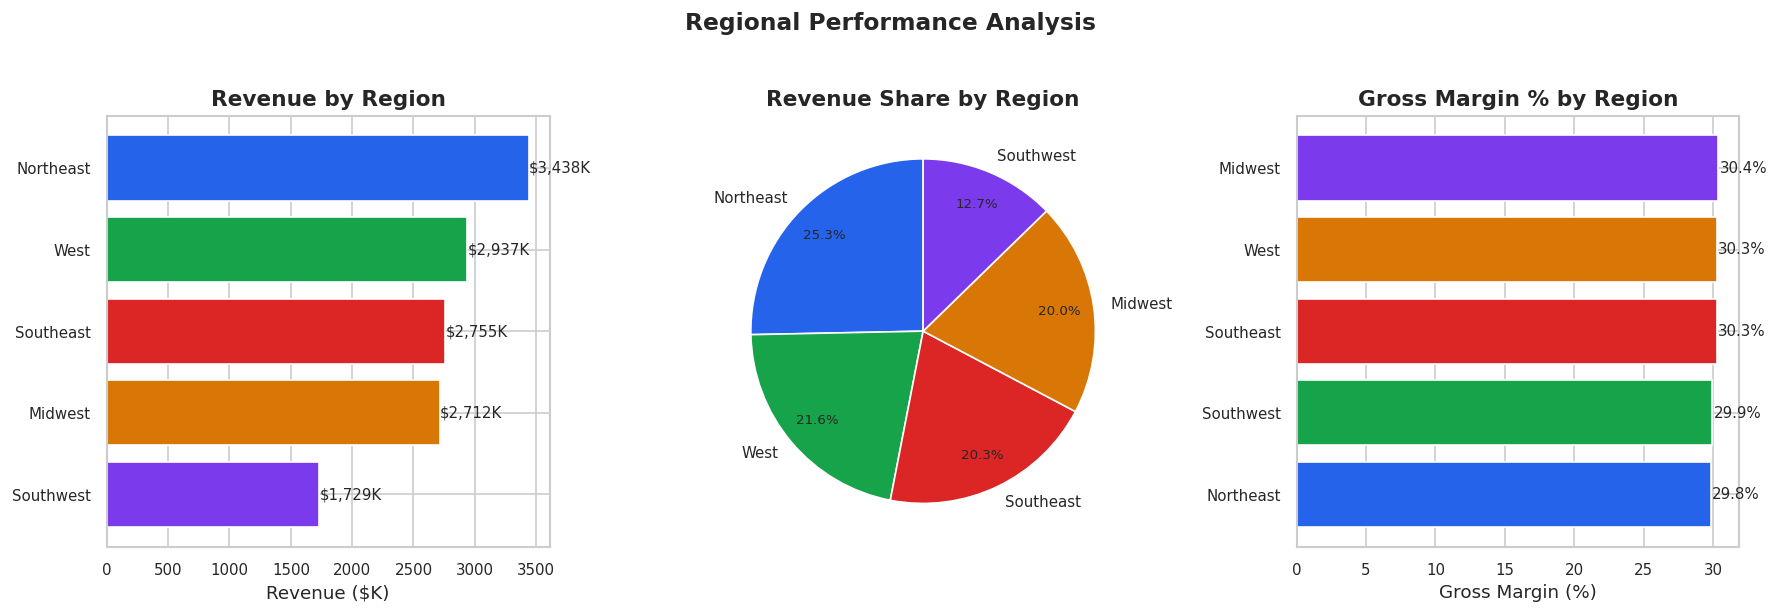

Insight: Northeast leads with 25.3% of total revenue.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Revenue by region
ax = axes[0]
bars = ax.barh(regional['region'], regional['revenue'] / 1000,
               color=BRAND_COLORS[:len(regional)])
for bar, val in zip(bars, regional['revenue'] / 1000):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}K', va='center', fontsize=9)
ax.set_title('Revenue by Region')
ax.set_xlabel('Revenue ($K)')
ax.invert_yaxis()

# Revenue share pie
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    regional['revenue_share'],
    labels=regional['region'],
    autopct='%1.1f%%',
    colors=BRAND_COLORS[:len(regional)],
    startangle=90,
    pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(8)
ax.set_title('Revenue Share by Region')

# Margin by region
ax = axes[2]
margin_sorted = regional.sort_values('margin', ascending=True)
bars = ax.barh(margin_sorted['region'], margin_sorted['margin'] * 100,
               color=BRAND_COLORS[:len(margin_sorted)])
for bar, val in zip(bars, margin_sorted['margin'] * 100):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('Gross Margin % by Region')
ax.set_xlabel('Gross Margin (%)')

plt.suptitle('Regional Performance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/cleaned/03_regional_performance.png', bbox_inches='tight')
plt.show()

top_region = regional.iloc[0]['region']
top_share  = regional.iloc[0]['revenue_share']
print(f"Insight: {top_region} leads with {top_share:.1f}% of total revenue.")

In [17]:
category = (
    df.groupby('product_category')
    .agg(
        revenue=('revenue', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        orders=('order_id', 'count'),
        units=('units_sold', 'sum'),
        margin=('gross_margin_pct', 'mean'),
        aov=('revenue', 'mean')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)
category['revenue_share'] = (category['revenue'] / category['revenue'].sum() * 100).round(1)
category

,product_category,revenue,gross_profit,orders,units,margin,aov,revenue_share
1,Electronics,6124809.76,637671.65,2353,12553,0.11,2602.98,45.10
2,Home & Garden,3025841.69,913381.28,2366,12604,0.31,1278.88,22.30
4,Sports,2234316.07,566114.41,2465,12909,0.26,906.42,16.50
0,Apparel,1271140.58,555533.24,2380,12547,0.44,534.09,9.40
3,Office Supplies,916307.39,352201.36,2436,12551,0.39,376.15,6.80


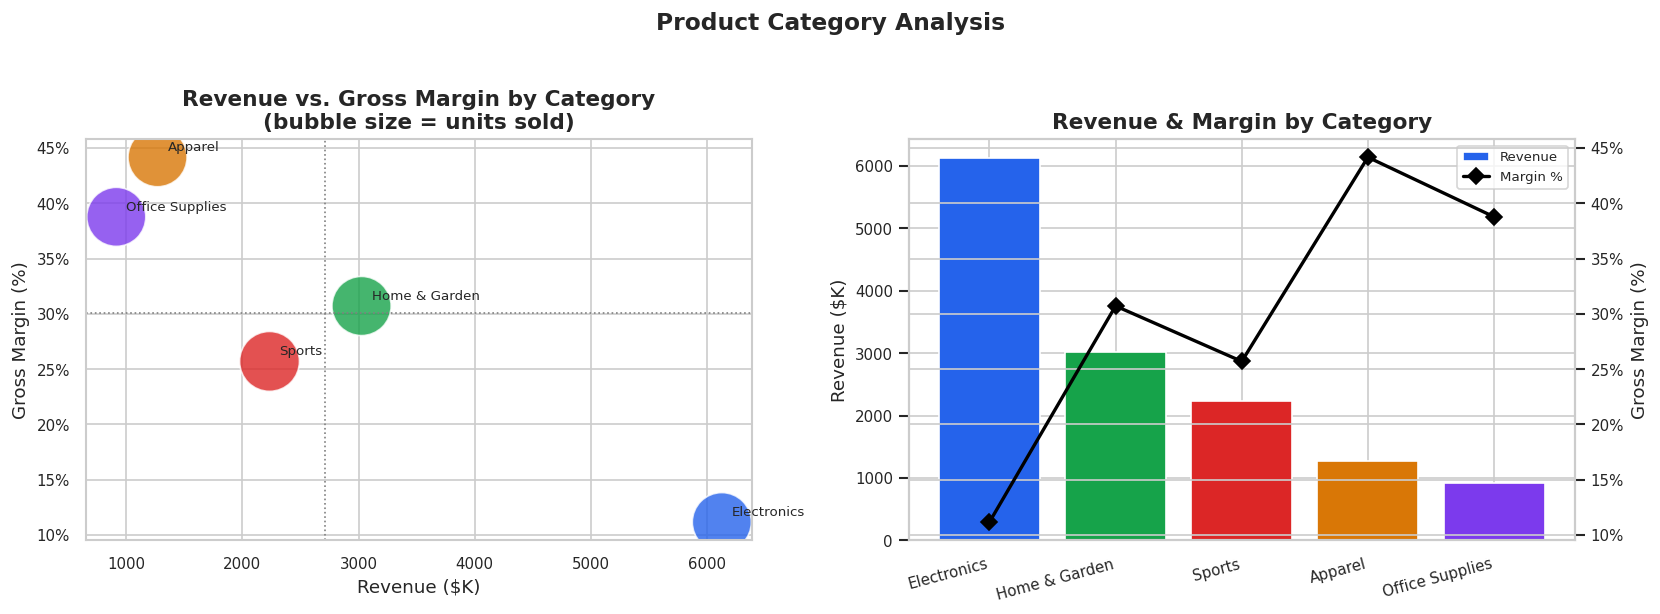

Insight: Electronics drives the most revenue. Apparel has the highest margin — ideal upsell target.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue vs Margin scatter — the key strategic view
ax = axes[0]
scatter = ax.scatter(
    category['revenue'] / 1000,
    category['margin'] * 100,
    s=category['units'] / 10,   # bubble size = units sold
    c=BRAND_COLORS[:len(category)],
    alpha=0.8,
    edgecolors='white',
    linewidths=1
)
for _, row in category.iterrows():
    ax.annotate(
        row['product_category'],
        (row['revenue'] / 1000, row['margin'] * 100),
        textcoords='offset points', xytext=(6, 4), fontsize=8
    )
ax.axvline(category['revenue'].mean() / 1000, color='gray', linestyle=':', linewidth=1)
ax.axhline(category['margin'].mean() * 100, color='gray', linestyle=':', linewidth=1)
ax.set_title('Revenue vs. Gross Margin by Category\n(bubble size = units sold)')
ax.set_xlabel('Revenue ($K)')
ax.set_ylabel('Gross Margin (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Category revenue bars with margin overlay
ax2 = axes[1]
x = range(len(category))
bars = ax2.bar(x, category['revenue'] / 1000, color=BRAND_COLORS[:len(category)], label='Revenue')
ax2.set_xticks(x)
ax2.set_xticklabels(category['product_category'], rotation=15, ha='right')
ax2.set_ylabel('Revenue ($K)')
ax2.set_title('Revenue & Margin by Category')

ax_twin = ax2.twinx()
ax_twin.plot(x, category['margin'] * 100, color='black', marker='D',
             linewidth=2, markersize=7, label='Margin %')
ax_twin.set_ylabel('Gross Margin (%)')
ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

plt.suptitle('Product Category Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/cleaned/04_category_analysis.png', bbox_inches='tight')
plt.show()

high_rev  = category.iloc[0]['product_category']
high_marg = category.loc[category['margin'].idxmax(), 'product_category']
print(f"Insight: {high_rev} drives the most revenue. {high_marg} has the highest margin — ideal upsell target.")

In [19]:
# Top 10 individual products by revenue
top_products = (
    df.groupby('product_name')
    .agg(revenue=('revenue', 'sum'), orders=('order_id', 'count'), margin=('gross_margin_pct', 'mean'))
    .reset_index()
    .sort_values('revenue', ascending=False)
    .head(10)
)
top_products['revenue'] = top_products['revenue'].apply(lambda x: f'${x:,.0f}')
top_products['margin'] = top_products['margin'].apply(lambda x: f'{x:.1%}')
top_products

,product_name,revenue,orders,margin
2,Bluetooth Speaker,"$1,049,459",398,11.8%
25,Webcam,"$1,033,351",394,10.8%
16,Portable Charger,"$1,033,057",385,11.1%
21,Tablet,"$1,023,415",395,10.6%
28,Wireless Headphones,"$997,025",377,11.4%
19,Smart Watch,"$988,502",404,11.3%
22,Throw Blanket,"$541,216",398,31.1%
3,Candle Set,"$521,873",413,30.6%
10,LED Desk Lamp,"$496,797",392,29.8%
14,Plant Pot Set,"$493,880",374,30.9%


In [20]:
reps = (
    df[df['sales_rep'] != 'Unknown']
    .groupby(['sales_rep', 'region'])
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'count'),
        aov=('revenue', 'mean'),
        margin=('gross_margin_pct', 'mean'),
        target=('daily_target', 'sum'),
        units=('units_sold', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)
reps['target_ach'] = (reps['revenue'] / reps['target'] * 100).round(1)
reps['rank'] = range(1, len(reps) + 1)
reps

,sales_rep,region,revenue,orders,aov,margin,target,units,target_ach,rank
9,Priya Sharma,Northeast,1759784.36,1515,1161.57,0.30,2147466.10,8022,81.90,1
7,Marcus Thompson,Northeast,1641835.17,1465,1120.71,0.30,2076799.33,7735,79.10,2
2,Chen Wei,West,1495321.62,1288,1160.96,0.30,1805066.05,6991,82.80,3
10,Ryan Mitchell,West,1419773.78,1299,1092.97,0.30,1851932.58,6757,76.70,4
5,James O'Brien,Southeast,1380345.42,1218,1133.29,0.31,1720599.46,6251,80.20,5
11,Sofia Rodriguez,Southeast,1350994.03,1243,1086.88,0.30,1757399.25,6355,76.90,6
3,David Kim,Midwest,1349129.40,1161,1162.04,0.30,1630332.94,6435,82.80,7
0,Aisha Patel,Midwest,1338173.37,1188,1126.41,0.30,1699132.63,6256,78.80,8
8,Olivia Foster,Southwest,436796.62,372,1174.18,0.31,521266.49,1974,83.80,9
4,Emily Nakamura,Southwest,434337.47,354,1226.94,0.29,499666.48,1845,86.90,10


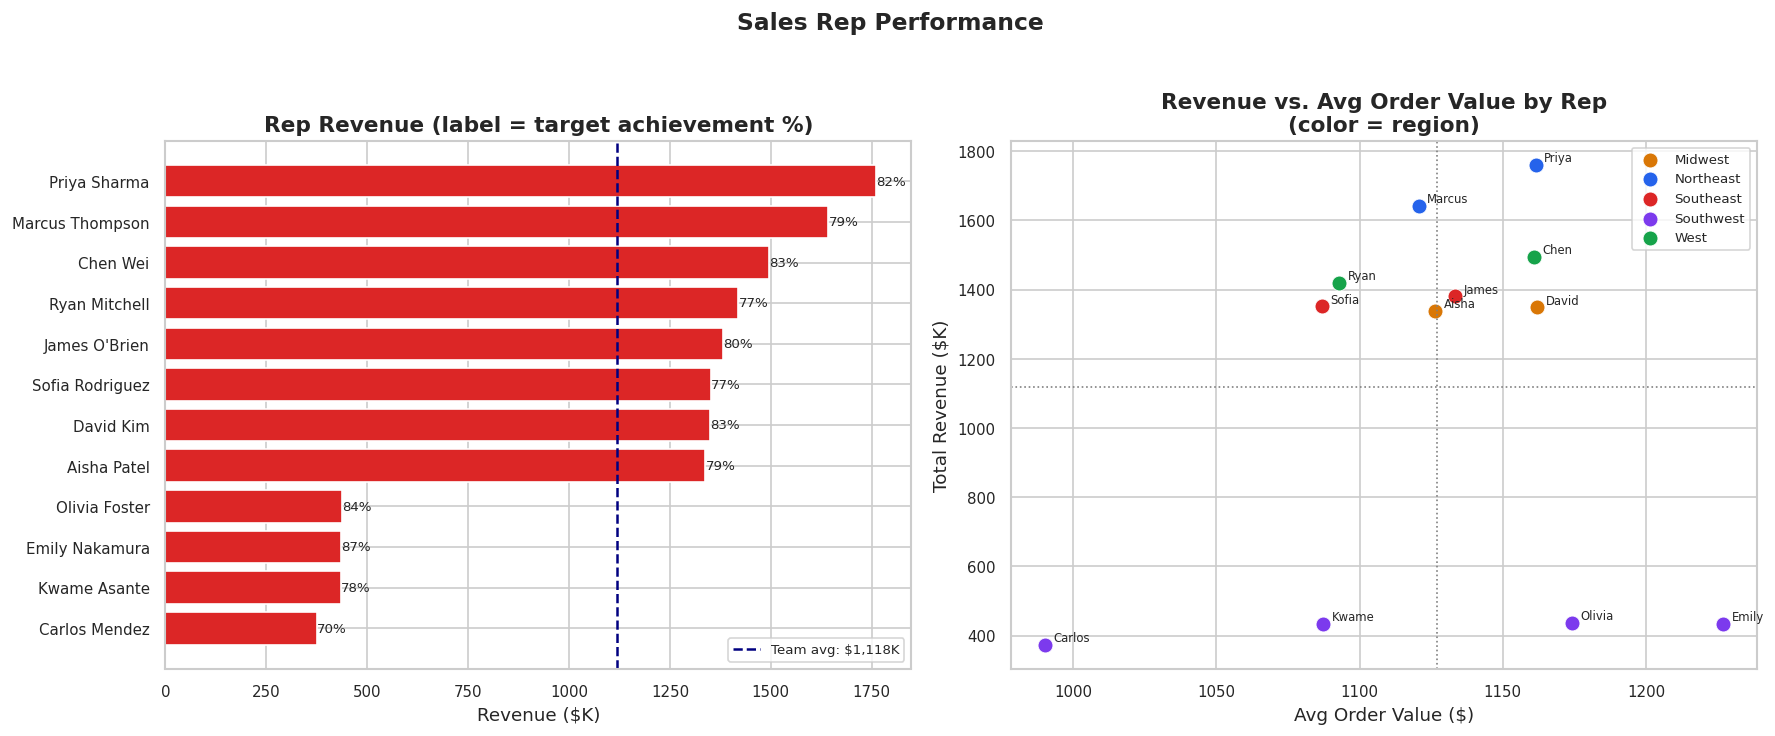

Insight: Priya Sharma leads. Gap between #1 and #12: 370% — coaching opportunity for bottom performers.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Rep revenue ranking
ax = axes[0]
colors = [BRAND_COLORS[1] if v >= 100 else BRAND_COLORS[2] for v in reps['target_ach']]
bars = ax.barh(reps['sales_rep'], reps['revenue'] / 1000, color=colors)
ax.axvline(reps['revenue'].mean() / 1000, color='navy', linestyle='--',
           linewidth=1.5, label=f'Team avg: ${reps["revenue"].mean()/1000:,.0f}K')
for bar, tgt in zip(bars, reps['target_ach']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{tgt:.0f}%', va='center', fontsize=8)
ax.set_title('Rep Revenue (label = target achievement %)')
ax.set_xlabel('Revenue ($K)')
ax.invert_yaxis()
ax.legend(fontsize=8)

# Revenue vs AOV scatter — identifies high-value reps
ax = axes[1]
region_colors = {r: c for r, c in zip(reps['region'].unique(), BRAND_COLORS)}
for region, group in reps.groupby('region'):
    ax.scatter(group['aov'], group['revenue'] / 1000,
               label=region, s=80, color=region_colors[region], edgecolors='white', linewidths=0.5)
    for _, row in group.iterrows():
        ax.annotate(row['sales_rep'].split()[0],
                    (row['aov'], row['revenue'] / 1000),
                    textcoords='offset points', xytext=(5, 2), fontsize=7)

ax.axvline(reps['aov'].mean(), color='gray', linestyle=':', linewidth=1)
ax.axhline(reps['revenue'].mean() / 1000, color='gray', linestyle=':', linewidth=1)
ax.set_title('Revenue vs. Avg Order Value by Rep\n(color = region)')
ax.set_xlabel('Avg Order Value ($)')
ax.set_ylabel('Total Revenue ($K)')
ax.legend(fontsize=8)

plt.suptitle('Sales Rep Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/cleaned/05_rep_performance.png', bbox_inches='tight')
plt.show()

top_rep   = reps.iloc[0]['sales_rep']
top_rev   = reps.iloc[0]['revenue']
bottom_rep = reps.iloc[-1]['sales_rep']
gap = (top_rev - reps.iloc[-1]['revenue']) / reps.iloc[-1]['revenue'] * 100
print(f"Insight: {top_rep} leads. Gap between #1 and #12: {gap:.0f}% — coaching opportunity for bottom performers.")

In [22]:
segments = (
    df.groupby('customer_segment')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'count'),
        aov=('revenue', 'mean'),
        units=('units_sold', 'mean'),
        discount=('discount_pct', 'mean'),
        margin=('gross_margin_pct', 'mean')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)
segments['revenue_share'] = (segments['revenue'] / segments['revenue'].sum() * 100).round(1)
segments

,customer_segment,revenue,orders,aov,units,discount,margin,revenue_share
1,Corporate,6944617.27,3675,1889.69,8.83,0.09,0.28,51.20
0,Consumer,3867573.18,5917,653.64,2.95,0.04,0.31,28.50
2,Small Business,2760225.04,2408,1146.27,5.51,0.04,0.32,20.30


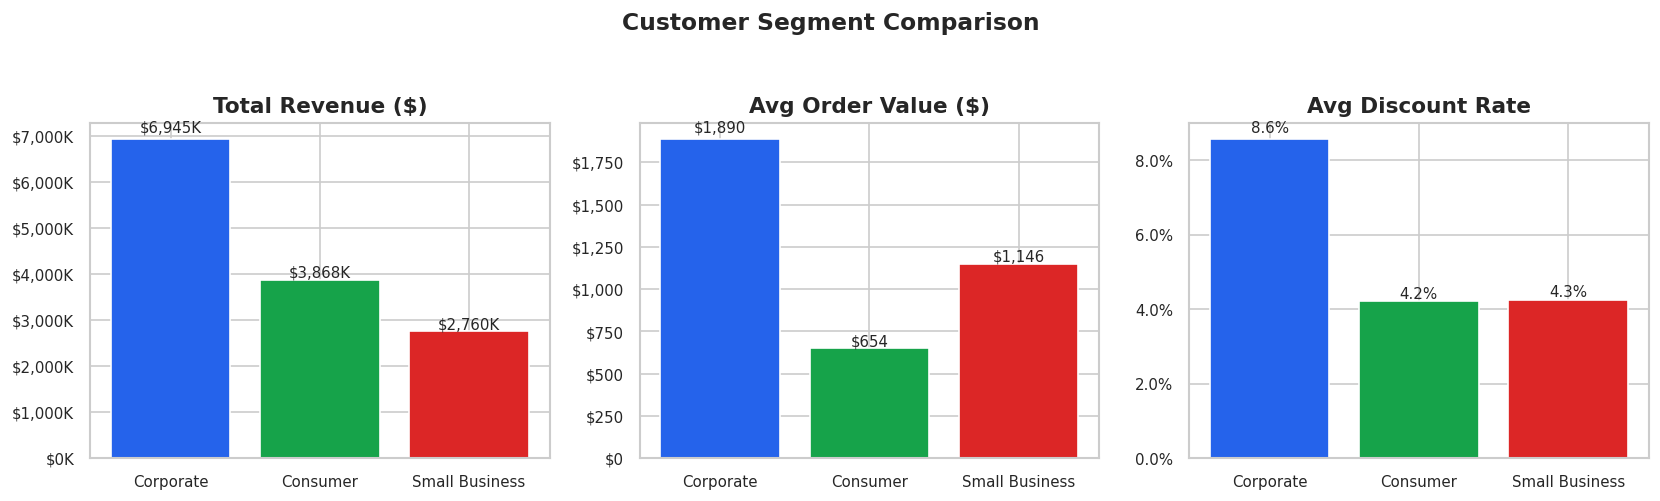

Insight: Corporate accounts for 51.2% of revenue with the highest AOV — protect and grow this segment.


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ['revenue', 'aov', 'discount']
titles  = ['Total Revenue ($)', 'Avg Order Value ($)', 'Avg Discount Rate']
fmts    = [lambda x, _: f'${x/1000:,.0f}K', lambda x, _: f'${x:,.0f}', lambda x, _: f'{x:.1%}']

for ax, metric, title, fmt in zip(axes, metrics, titles, fmts):
    bars = ax.bar(segments['customer_segment'], segments[metric],
                  color=BRAND_COLORS[:len(segments)])
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                fmt(bar.get_height(), None), ha='center', fontsize=9)

plt.suptitle('Customer Segment Comparison', fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('../data/cleaned/06_segments.png', bbox_inches='tight')
plt.show()

corp_share = segments.loc[segments['customer_segment'] == 'Corporate', 'revenue_share'].values[0]
print(f"Insight: Corporate accounts for {corp_share:.1f}% of revenue with the highest AOV — protect and grow this segment.")

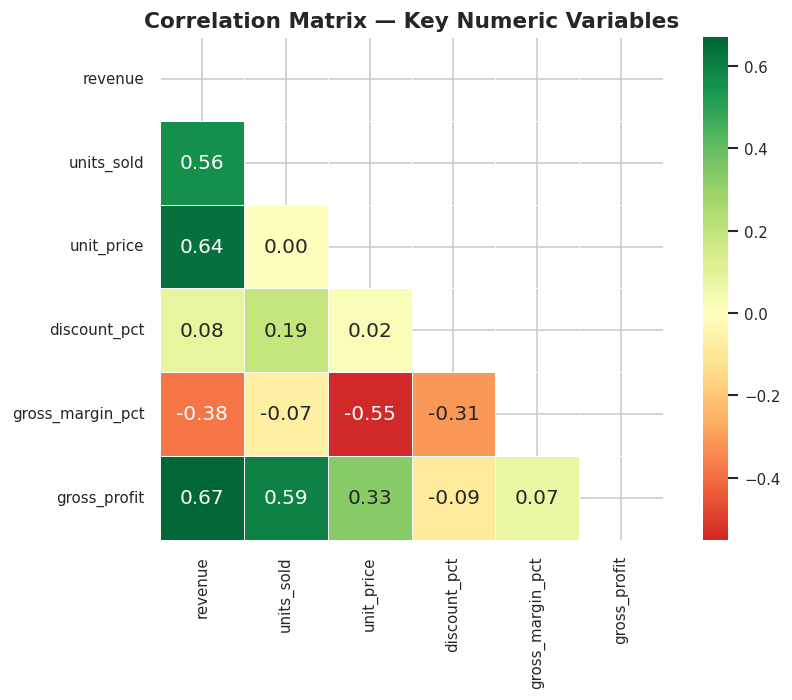

Insight: Discount ↔ Margin correlation = -0.31 — discounting erodes margin as expected.


In [24]:
corr_cols = ['revenue', 'units_sold', 'unit_price', 'discount_pct', 'gross_margin_pct', 'gross_profit']
corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix — Key Numeric Variables', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/cleaned/07_correlation.png', bbox_inches='tight')
plt.show()

discount_rev_corr = corr_matrix.loc['discount_pct', 'gross_margin_pct']
print(f"Insight: Discount ↔ Margin correlation = {discount_rev_corr:.2f} — discounting erodes margin as expected.")

In [25]:
print("=" * 55)
print("  TOP 5 DASHBOARD KPIs")
print("=" * 55)
print(f"  1. Total Revenue:        ${total_revenue:>12,.2f}")
print(f"  2. Gross Margin %:       {avg_margin:>12.1%}")
print(f"  3. Avg Order Value:      ${aov:>12,.2f}")
print(f"  4. Target Achievement:   {target_ach:>12.1%}")
print(f"  5. MoM Growth (Dec):     {monthly['mom_growth'].iloc[-1]:>12.1f}%")
print()
print("  KEY BUSINESS INSIGHTS")
print("-" * 55)
print(f"  • Q4 drives {monthly.loc[monthly['order_month'] >= 10, 'revenue'].sum() / total_revenue:.0%} of annual revenue — strong seasonality")
print(f"  • {high_rev} = highest revenue, {high_marg} = highest margin")
print(f"  • Corporate segment has highest AOV despite lowest order count")
print(f"  • Discount rate negatively correlates with margin ({discount_rev_corr:.2f})")
print(f"  • {top_region} leads all regions in revenue")

  TOP 5 DASHBOARD KPIs
  1. Total Revenue:        $13,572,415.49
  2. Gross Margin %:              30.2%
  3. Avg Order Value:      $    1,131.03
  4. Target Achievement:          80.0%
  5. MoM Growth (Dec):             18.2%

  KEY BUSINESS INSIGHTS
-------------------------------------------------------
  • Q4 drives 30% of annual revenue — strong seasonality
  • Electronics = highest revenue, Apparel = highest margin
  • Corporate segment has highest AOV despite lowest order count
  • Discount rate negatively correlates with margin (-0.31)
  • Northeast leads all regions in revenue


In [26]:
import os
os.makedirs('../data/cleaned', exist_ok=True)

# Export metrics summary for reference
metrics_summary = pd.DataFrame([
    {'metric': 'Total Revenue',        'value': round(total_revenue, 2),  'unit': '$'},
    {'metric': 'Gross Profit',         'value': round(gross_profit, 2),   'unit': '$'},
    {'metric': 'Avg Gross Margin',     'value': round(avg_margin, 4),     'unit': '%'},
    {'metric': 'Total Orders',         'value': total_orders,             'unit': 'count'},
    {'metric': 'Avg Order Value',      'value': round(aov, 2),            'unit': '$'},
    {'metric': 'Total Units Sold',     'value': total_units,              'unit': 'count'},
    {'metric': 'Avg Discount Rate',    'value': round(avg_discount, 4),   'unit': '%'},
    {'metric': 'Target Achievement',   'value': round(target_ach, 4),     'unit': '%'},
    {'metric': 'Active Sales Reps',    'value': unique_reps,              'unit': 'count'},
    {'metric': 'Best Month Revenue',   'value': round(monthly['revenue'].max(), 2), 'unit': '$'},
    {'metric': 'Best Month',           'value': best_month,               'unit': 'text'},
    {'metric': 'Top Region',           'value': top_region,               'unit': 'text'},
    {'metric': 'Top Rep',              'value': top_rep,                  'unit': 'text'},
    {'metric': 'Top Category Revenue', 'value': high_rev,                 'unit': 'text'},
    {'metric': 'Top Category Margin',  'value': high_marg,                'unit': 'text'},
])

metrics_summary.to_csv('../data/cleaned/metrics_summary.csv', index=False)
print("✓ Exported metrics_summary.csv")
metrics_summary

✓ Exported metrics_summary.csv


,metric,value,unit
0,Total Revenue,13572415.49,$
1,Gross Profit,3024901.94,$
2,Avg Gross Margin,0.30,%
3,Total Orders,12000,count
4,Avg Order Value,1131.03,$
5,Total Units Sold,63164,count
6,Avg Discount Rate,0.06,%
7,Target Achievement,0.80,%
8,Active Sales Reps,12,count
9,Best Month Revenue,1623812.27,$
